# AWQ Diagnostic Notebook

**目的：不是量化模型，而是理解量化為什麼會崩潰**

流程：
1. Cell 1-2: 環境設置 + 載入模型
2. Cell 3-4: 收集 activation 統計量
3. Cell 5: 視覺化 AWQ 的 weight importance（paper Figure 1 的復現）
4. Cell 6: Per-layer kurtosis 分析（outlier 嚴重程度）
5. Cell 7: **核心實驗** — bit-width sweep，觀察 phase transition
6. Cell 8: Kurtosis vs Phase Transition 相關性分析

預計時間：LLaMA-3.2 1B 全部跑完約 30 分鐘（RTX 5060 Ti 16GB）

## Cell 1: 環境設置

In [1]:
import sys
print(sys.executable)

/home/lewis/micromamba/envs/llm-opt/bin/python3.10


In [2]:
# 如果還沒裝，先裝這些
# !pip install transformers accelerate torch matplotlib seaborn numpy

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import defaultdict, OrderedDict
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm.auto import tqdm

plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
VRAM: 16.6 GB


## Cell 2: 載入模型 + Tokenizer

建議從 1B 開始（快、VRAM 小、phase transition 更明顯）

In [3]:
# === 選一個模型 ===
model_name = "Qwen/Qwen2.5-1.5B"  # ~2.4 GB VRAM, 快速迭代
# model_name = "meta-llama/Llama-3.2-1B"  # ~2.4 GB VRAM, 快速迭代
# model_name = "meta-llama/Llama-3.2-3B"  # ~6.5 GB VRAM
# model_name = "meta-llama/Llama-2-7b-hf" # ~14 GB VRAM, 接近你 5060Ti 上限

print(f"Loading {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager"
)
model.eval()
print(f"Model loaded. Parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

Loading Qwen/Qwen2.5-1.5B...
Model loaded. Parameters: 1.54B


## Cell 2.5: 觀察 Model

In [4]:
# === 模型架構探索 ===

# 1. 最高層結構
print("=== 頂層結構 ===")
for name, module in model.named_children():
    print(f"  {name}: {type(module).__name__}")

print()

# 2. 第一個 transformer block 的內部結構
print("=== 第 0 個 Transformer Block 內部 （28 個 block 結構完全相同）===")
print("===           並不是實際執行順序，要看forward才知道            ===")
for name, module in model.model.layers[0].named_modules():
    print(f"  {name:40s} {type(module).__name__:20s}", end="")
    if isinstance(module, torch.nn.Linear):
        print(f"  in={module.in_features}, out={module.out_features}", end="")
    print()

print()

# 3. 總共幾個 layer
print(f"=== 總覽 ===")
print(f"Transformer blocks 數量: {len(model.model.layers)}")
print(f"Hidden dim: {model.config.hidden_size}")
print(f"Attention heads: {model.config.num_attention_heads}")
print(f"KV heads: {model.config.num_key_value_heads}")
print(f"FFN intermediate dim: {model.config.intermediate_size}")

print()

# 4. 所有 Linear layer 的名字和 shape
print("=== 所有 Linear layers（只印第 0 個 block）===")
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Linear):
        if "layers.0" in name:
            print(f"  {name:60s}  [{module.in_features} → {module.out_features}]")

=== 頂層結構 ===
  model: Qwen2Model
  lm_head: Linear

=== 第 0 個 Transformer Block 內部 （28 個 block 結構完全相同）===
===           並不是實際執行順序，要看forward才知道            ===
                                           Qwen2DecoderLayer   
  self_attn                                Qwen2Attention      
  self_attn.q_proj                         Linear                in=1536, out=1536
  self_attn.k_proj                         Linear                in=1536, out=256
  self_attn.v_proj                         Linear                in=1536, out=256
  self_attn.o_proj                         Linear                in=1536, out=1536
  mlp                                      Qwen2MLP            
  mlp.gate_proj                            Linear                in=1536, out=8960
  mlp.up_proj                              Linear                in=1536, out=8960
  mlp.down_proj                            Linear                in=8960, out=1536
  mlp.act_fn                               SiLUActivation      
  input

### BertViz: Attention 視覺化
12個Head, 28個Block

Bolck i 的output 是 Block i+1 的 Input

這裡的attention是指 weights, 也就是softmax之後，即將要跟V相乘的矩陣

不是指真正attention算出來的值

In [5]:
# === BertViz: Attention 視覺化 ===
# pip install bertviz

from bertviz import model_view

# 跑一次 forward，拿 attention weights
sample_text = "The transformer architecture relies on self-attention mechanisms."
inputs = tokenizer(sample_text, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(
        **inputs,
        output_attentions=True
    )

# 整理格式
# outputs.attentions 是 softmax 之後、乘以 V 之前的那個矩陣：
# 每個 token 對每個 token 的注意力分配比例
# 不是指乘上V之後，的實際的資訊內容
attention = outputs.attentions   # tuple，長度 = 28（每個 block 一個）
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

print(f"Token 數量: {len(tokens)}")
print(f"Tokens: {tokens}")
print(f"Attention tuple 長度: {len(attention)}")
print(f"每個 attention 的 shape: {attention[0].shape}")
# 預期: [1, num_heads, seq_len, seq_len]
#        ↑  ↑          ↑        ↑
#      batch head     from_token to_token

# 視覺化（在 Jupyter 裡會 inline 顯示互動式介面）
model_view(attention, tokens)

Token 數量: 10
Tokens: ['The', 'Ġtransformer', 'Ġarchitecture', 'Ġrelies', 'Ġon', 'Ġself', '-', 'attention', 'Ġmechanisms', '.']
Attention tuple 長度: 28
每個 attention 的 shape: torch.Size([1, 12, 10, 10])


<IPython.core.display.Javascript object>

## Cell 3: 準備 Calibration Data

跟 AWQ 一樣用一小段 text 做 calibration，收集 activation 分布

### Cell 3-1: 觀察 Tokenizer
Tokenizer 是死的查表（但也是train出來的），跟語意無關。
不同 tokenizer 切法不同。
Qwen 的 tokenizer 和 LLaMA 的 tokenizer 用的 vocabulary 不一樣，同一句話會切出不同數量的 token。
甚至同一個 tokenizer，不同語言的效率也不同

同一個 byte sequence 永遠對應同一個 ID。

"make" 永遠是 6927

" make" 永遠是 1281

Tokenizer 不認識「單詞」，它只認識 byte pattern。

```
輸入文字: "hello world"
         ↓ tokenizer(查表)
token ids: [9906, 1917]          ← 每個 token 對應一個整數 id
         ↓ Embedding table（查表）
x: [1, 2, 1536]                  ← 每個 token 變成一個 1536 維的向量
```

In [6]:
print(tokenizer.encode("make"))
print(tokenizer.encode("I make food"))
print(tokenizer.encode("I make a decision"))
print(tokenizer.encode("Hello"))
print(tokenizer.encode("hello"))
print(tokenizer.encode(" world"))

print(tokenizer.decode([6927]))   # → "make"
print(tokenizer.decode([1281]))   # → " make" (前面有空格)

[6927]
[40, 1281, 3607]
[40, 1281, 264, 5480]
[9707]
[14990]
[1879]
make
 make


In [7]:
# 簡易 calibration: 用幾段隨機 text
# AWQ 原版用 128 個 Pile 樣本，這裡我們用少量就夠做 diagnosis
calibration_texts = [
    "The transformer architecture was introduced in the paper Attention Is All You Need. "
    "It relies entirely on self-attention mechanisms to draw global dependencies between "
    "input and output. The key innovation was replacing recurrent layers with multi-head "
    "attention, allowing for significantly more parallelization during training.",
    
    "In mathematics, a matrix is a rectangular array of numbers arranged in rows and columns. "
    "The individual items in a matrix are called its elements or entries. Matrices have wide "
    "applications in engineering, physics, economics, and statistics. The determinant of a "
    "square matrix is a scalar value that encodes certain properties of the linear transformation.",
    
    "Machine learning is a subset of artificial intelligence that provides systems the ability "
    "to automatically learn and improve from experience without being explicitly programmed. "
    "The process begins with observations or data, such as examples, direct experience, or "
    "instruction, in order to look for patterns in data and make better decisions.",
    
    "Quantization reduces the precision of weights and activations in neural networks from "
    "floating point to lower bit-width integers. This compression technique significantly "
    "reduces memory footprint and enables faster inference on hardware that supports integer "
    "arithmetic. However, aggressive quantization can lead to accuracy degradation.",
]

print(f"Calibration samples: {len(calibration_texts)}")
print(f"Tokenizing...")

cal_tokens = [
    tokenizer(t, return_tensors="pt", truncation=True, max_length=512)
    for t in calibration_texts
]
print(f"Token lengths: {[t['input_ids'].shape[1] for t in cal_tokens]}")

Calibration samples: 4
Tokenizing...
Token lengths: [52, 65, 56, 50]


## Cell 4: 收集 Activation 統計量

這裡我們用 forward hook 攔截每個 Linear layer 的 input activation，
計算 AWQ 需要的 channel magnitude，以及額外的 kurtosis/outlier ratio

Hook 是 PyTorch 的機制：你可以在任何 layer 上掛一個 callback function，每次那個 layer 被執行時，PyTorch 會自動呼叫你的 function，把 input 和 output 傳給你。這就是我們「攔截」activation 的方式。

### Hook 裡面算了 5 個統計量（全部都是 per-channel）：

到了 Linear layer 的輸入時，已經不是「剛 embedding 完」了。每個 token 的向量在經過前面幾層 attention + FFN 後已經被更新過。
但 shape 不變，始終是 `[1, 52, 1536]`。

```
Token 0:  [0.23, -0.51, 0.87, ..., 0.14]  ← 1536 個數字
Token 1:  [0.11, -3.72, 0.65, ..., 0.08]
Token 2:  [0.19, -0.48, 0.91, ..., 0.22]
...
Token 51: [0.31, -0.55, 0.73, ..., 0.17]

           ch0    ch1    ch2   ...  ch1535
```
`channel_magnitude` — 每個 channel（1536 維裡的每一維）的平均絕對值。這就是 AWQ 用來判斷 weight importance 的核心 signal。 如果第 j 個 channel 的 activation 值很大，代表這個 channel 對模型輸出影響大，量化它的 weight 時要更小心。

`channel_variance` — 每個 channel 的 variance。Variance 大代表值的分散程度大，量化時更容易損失資訊。

`kurtosis` — 尖峰度。先標準化成 z-score，然後算四次方的平均，再減 3（Normal distribution 的 kurtosis = 3，減掉後叫 excess kurtosis）。Kurtosis 高代表 heavy tail，也就是 outlier 嚴重。 這是 Cell 8 要拿來做 phase transition prediction 的關鍵指標。

`channel_max` — 每個 channel 的最大絕對值。

`outlier_ratio` — 超過 6σ 的值的比例。正常來說幾乎應該是 0，但 LLM 裡某些 channel 的 outlier ratio 可以到 0.01 甚至更高。


---
#### kurt = z.pow(4).mean(dim=(0, 1)) - 3.0?

正態分布的 kurtosis 理論值剛好等於 3
所以 `-3.0` 的目的是把正態分布當作基準零點：
```
excess kurtosis = 0   → 跟正態分布一樣正常
excess kurtosis > 0   → 比正態分布更尖、尾巴更厚、outlier 更多
excess kurtosis < 0   → 比正態分布更平坦
```
---
#### 為什麼 outlier 門檻選 6σ，不選 3σ 或 10σ？
```
|x| > 3σ  → 約 0.27% 的點會超過  ← 太低，正常值也會被標記
|x| > 6σ  → 約 0.0000002%       ← 幾乎不可能是正常值
|x| > 10σ → 天文數字小           ← 太嚴，真正的 outlier 可能漏掉
```
6σ 的選擇邏輯是：在正態假設下，超過 6σ 幾乎不可能自然發生，所以超過的都是真正的結構性 outlier。

但這個假設本身有問題——LLM 的 activation 分布根本不是正態的（就是因為有 outlier 才在研究它）。

所以 6σ 在這裡更像是一個「夠極端」的工程門檻，而不是統計上嚴格推導出來的數字。

### 解釋
所以每次 hook 被觸發時，x 的 shape 是：
```
Sample 1: x [1, 78, 1536]   ← batch=1, seq_len=78
Sample 2: x [1, 91, 1536]   ← batch=1, seq_len=91
Sample 3: x [1, 83, 1536]   ← batch=1, seq_len=83
Sample 4: x [1, 95, 1536]   ← batch=1, seq_len=95
```

每次 `dim=(0,1)` 把那次的 batch×seq_len 壓掉，得到 `[1536]`，然後用 running average 累積：
```
第1次: ch_mag = mean over (1×78)  個值  → [1536]
第2次: ch_mag = mean over (1×91)  個值  → [1536]  → 跟第1次平均
第3次: ch_mag = mean over (1×83)  個值  → [1536]  → 跟前兩次平均
第4次: ch_mag = mean over (1×95)  個值  → [1536]  → 跟前三次平均
```

---

### 這裡有一個設計缺陷

Running average 是把 4 個 sample 的結果**等權重平均**，但 sample 長度不同——78 個 token 的結果跟 95 個 token 的結果各佔 1/4 權重，這其實不太公平。

嚴格來說應該要用 token 數量加權：

In [8]:
# === 收集 activation 統計量 ===
activation_stats = {}  # name -> { channel_magnitude, kurtosis, ... }
hooks = []

# === 你想保存原始 tensor 的 layer ===
# 選一個 attention 層 + 一個 MLP 層做對比
save_raw_layers = {
    'model.layers.0.self_attn.q_proj',
    'model.layers.0.mlp.gate_proj',
    'model.layers.13.self_attn.q_proj',  # 中間層
    'model.layers.27.self_attn.q_proj',  # 最後層
}

raw_activations = {}  # name -> list of tensors (一個 sample 一個)

def make_hook(name):
    """每個 Linear layer 的 forward hook"""
    def hook_fn(module, input, output):
        x = input[0].detach().float()  
        # [batch, seq_len, hidden_dim] 是通用寫法。
        # 在我們的 code 裡，每次只餵一段文字進去，所以 batch = 1
        # 實際 shape 就是 [1, 52, 1536]。
        # 如果你同時餵 4 段文字進去，batch 就是 4。寫 batch 只是習慣，代表這個維度可以變。
        
        # input[0] 就是這個 Linear layer 的輸入 activation
        # shape 是 [1, seq_len, hidden_dim]。
        # 比如 Qwen2.5-1.5B 的 hidden_dim = 1536，第一段 calibration text 有 52 個 token，所以 shape 是 [1, 52, 1536]。
        # .detach() 斷開梯度（我們不需要反向傳播）
        # .float() 從 FP16 轉成 FP32（避免統計量計算時的精度問題）。


        # Hook 裡面算了 5 個統計量：
        # Per-channel statistics
        # dim=(0, 1) = 「我不在意是哪個 batch、哪個 token，我只在意每個 channel（feature 維度） 平均有多大的激活值。」
        ch_mag = x.abs().mean(dim=(0, 1))           # AWQ 的 saliency signal
        ch_var = x.var(dim=(0, 1))
        ch_max = x.abs().amax(dim=(0, 1))

        # 原始 tensor 存起來（只存指定 layer）
        if name in save_raw_layers:
            if name not in raw_activations:
                raw_activations[name] = []
            raw_activations[name].append(x.cpu())  # [1, seq_len, d_model]
        
        # Kurtosis: 衡量 outlier 嚴重程度
        mu = x.mean(dim=(0, 1), keepdim=True)
        sigma = x.std(dim=(0, 1), keepdim=True).clamp(min=1e-8)
        z = (x - mu) / sigma
        kurt = z.pow(4).mean(dim=(0, 1)) - 3.0  # excess kurtosis
        
        # Outlier ratio: |x| > 6*std 的比例
        threshold = 6.0 * sigma.squeeze()
        outlier_mask = x.abs() > threshold.unsqueeze(0).unsqueeze(0)
        outlier_ratio = outlier_mask.float().mean(dim=(0, 1))
        
        # 累積（如果多個 calibration sample，取平均）
        # 4 個 calibration sample
        # 每個 sample 跑一次 forward pass
        # hook 會被觸發 4 次。
        # 希望最終結果是 4 次的平均，而不是只保留最後一次。

        # Hook 每次 forward pass 被呼叫時，同一個 layer 的 `name` 是固定的。所以：
        # - 第 1 個 sample → `else` 分支（初始化）
        # - 第 2、3、4 個 sample → `if` 分支（累積）
        # .cpu() 是把 tensor 從 GPU 記憶體搬回 CPU 記憶體。
        # 節省 VRAM：統計量不需要參與 GPU 運算，沒理由佔 GPU 記憶體
        if name in activation_stats: # 這個 layer 之前見過了 → 更新
            old = activation_stats[name]
            n = old['count']
            activation_stats[name] = {
                'channel_magnitude': (old['channel_magnitude'] * n + ch_mag.cpu()) / (n + 1),
                'channel_variance': (old['channel_variance'] * n + ch_var.cpu()) / (n + 1),
                'channel_max': torch.max(old['channel_max'], ch_max.cpu()),
                'kurtosis': (old['kurtosis'] * n + kurt.cpu()) / (n + 1),
                'outlier_ratio': (old['outlier_ratio'] * n + outlier_ratio.cpu()) / (n + 1),
                'hidden_dim': x.shape[-1],
                'count': n + 1,
            }
        else:   # 第一次見到這個 layer → 初始化
            activation_stats[name] = {
                'channel_magnitude': ch_mag.cpu(),
                'channel_variance': ch_var.cpu(),
                'channel_max': ch_max.cpu(),
                'kurtosis': kurt.cpu(),
                'outlier_ratio': outlier_ratio.cpu(),
                'hidden_dim': x.shape[-1],
                'count': 1,
            }
    return hook_fn

# 註冊 hooks
for name, module in model.named_modules():
    if isinstance(module, nn.Linear):
        hooks.append(module.register_forward_hook(make_hook(name)))

print(f"Registered {len(hooks)} hooks on Linear layers")

# Forward pass (收集 activation)
print("Running calibration forward passes...")
with torch.no_grad():
    for i, tokens in enumerate(cal_tokens):
        input_ids = tokens['input_ids'].to(device)
        model(input_ids)
        print(f"  Sample {i+1}/{len(cal_tokens)} done")

# 移除 hooks（重要！否則後續推論會很慢）
for h in hooks:
    h.remove()
hooks.clear()

print(f"\nCollected stats for {len(activation_stats)} layers")
print("Example layers:")
for name in list(activation_stats.keys())[:5]:
    s = activation_stats[name]
    print(f"  {name}: dim={s['hidden_dim']}, mean_kurtosis={s['kurtosis'].mean():.2f}")

Registered 197 hooks on Linear layers
Running calibration forward passes...
  Sample 1/4 done
  Sample 2/4 done
  Sample 3/4 done
  Sample 4/4 done

Collected stats for 197 layers
Example layers:
  model.layers.0.self_attn.q_proj: dim=1536, mean_kurtosis=-0.29
  model.layers.0.self_attn.k_proj: dim=1536, mean_kurtosis=-0.29
  model.layers.0.self_attn.v_proj: dim=1536, mean_kurtosis=-0.29
  model.layers.0.self_attn.o_proj: dim=1536, mean_kurtosis=1.54
  model.layers.0.mlp.gate_proj: dim=1536, mean_kurtosis=0.25


## Cell 5: 視覺化 Weight Importance（復現 AWQ Paper Figure 1）

你會看到經典的 hockey stick curve：
top 1% channel 的 importance 是其餘的 10-100 倍

---
input x:  [n, 1536]   ← hook 拿到這個

W:        [8960, 1536] ← PyTorch 的 Linear weight 是 [out, in]

output:   [n, 8960]   ← hook 不管這個

---
act_mag = channel_magnitude of input x
        → mean over (batch, seq_len), shape [1536]   # per input channel

weight_mag = W.abs().mean(dim=0)
           → mean over dim=0 (8960個output), shape [1536]  # per input channel

importance = weight_mag * act_mag
           → shape [1536]   # per input channel

---

In [9]:
# === 計算 AWQ-style weight importance ===
# importance[j] = mean(|W[:, j]|) * activation_magnitude[j]

importance_map = {}

for name, module in model.named_modules():
    if isinstance(module, nn.Linear) and name in activation_stats:
        W = module.weight.detach().cpu().float()
        act_mag = activation_stats[name]['channel_magnitude']
        
        weight_mag = W.abs().mean(dim=0)  # [in_features]
        importance = weight_mag * act_mag
        importance_map[name] = importance

print(f"Computed importance for {len(importance_map)} layers")

Computed importance for 197 layers


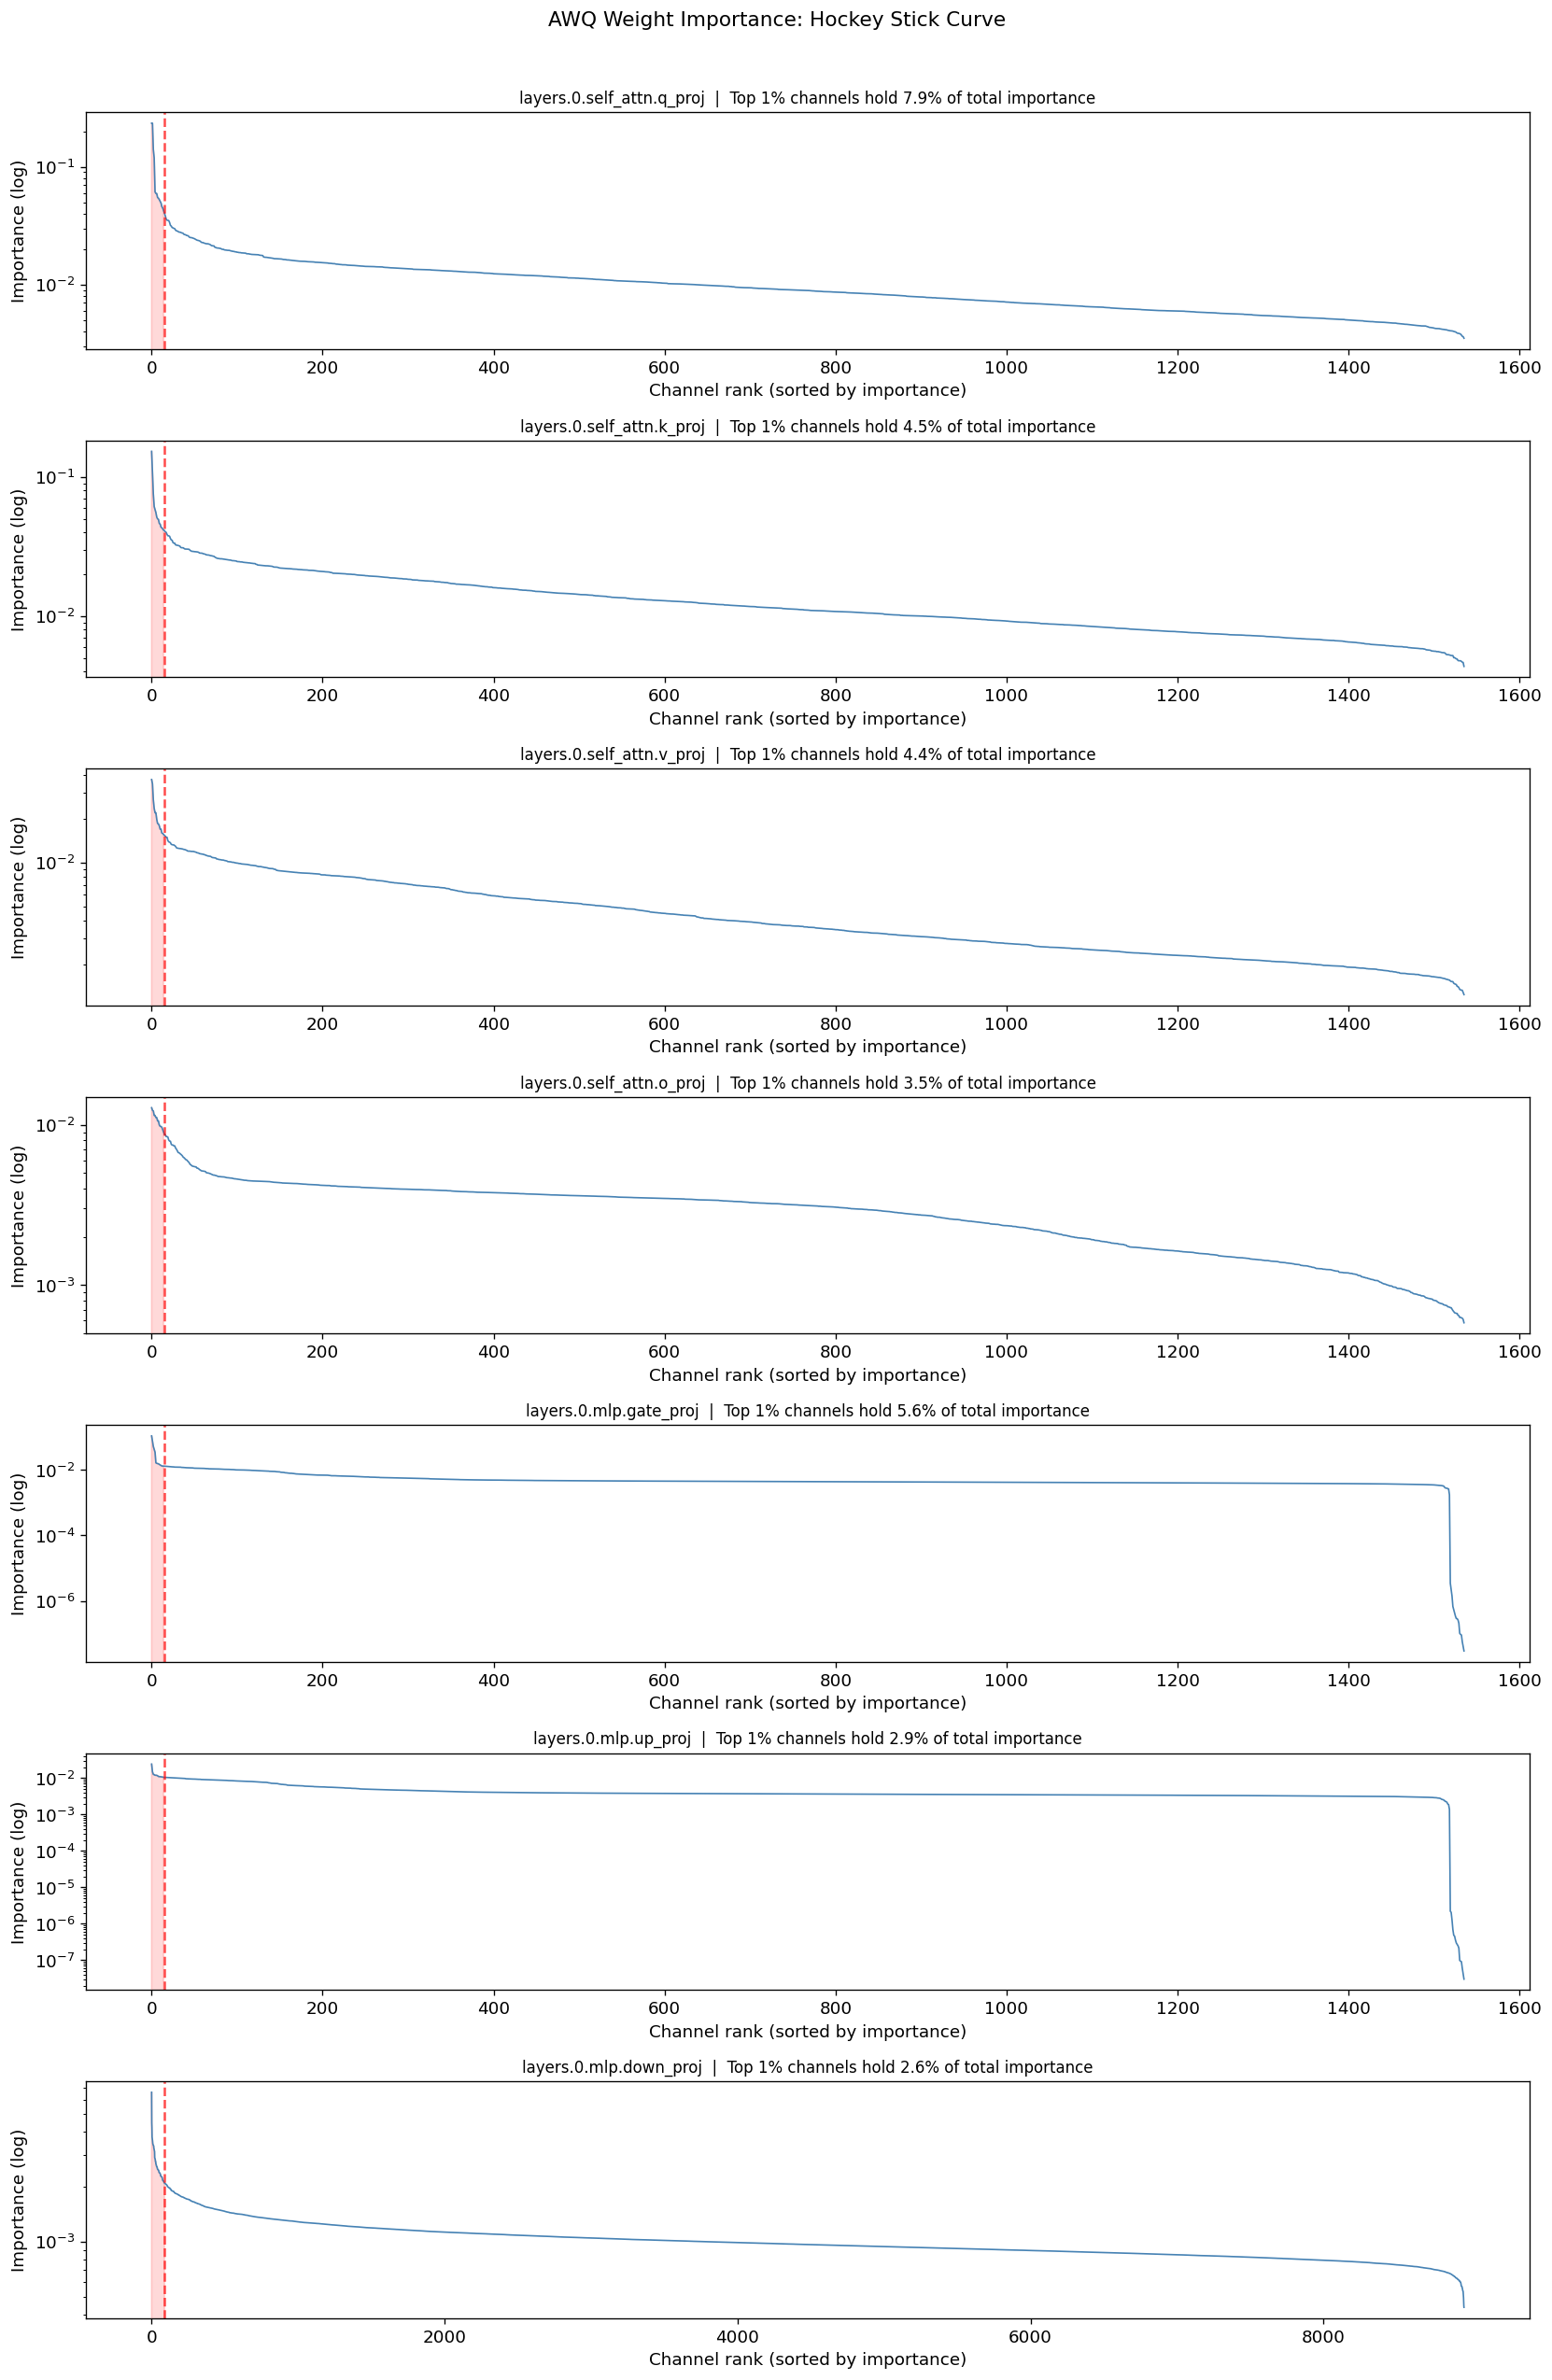


★ 觀察重點：
  - 曲線越陡 = saliency 越集中 = AWQ 的 scaling trick 效果越好
  - 如果曲線很平（importance 均勻分布），AWQ 就沒有優勢


In [10]:
# === 畫 Hockey Stick Curve ===
# 選幾個代表性的層來看

# 找到所有 layer 0 的 linear layers 作為示範
demo_layers = [n for n in importance_map.keys() if 'layers.0.' in n]

fig, axes = plt.subplots(len(demo_layers), 1, figsize=(14, 3 * len(demo_layers)))
if len(demo_layers) == 1:
    axes = [axes]

for ax, name in zip(axes, demo_layers):
    imp = importance_map[name].numpy()
    sorted_imp = np.sort(imp)[::-1]
    
    # 畫排序後的 importance（log scale）
    ax.semilogy(sorted_imp, linewidth=1.0, color='steelblue')
    
    # 標記 top 1%
    top1_idx = max(1, len(imp) // 100)
    ax.axvline(x=top1_idx, color='red', linestyle='--', alpha=0.7)
    ax.fill_between(range(top1_idx), sorted_imp[:top1_idx], alpha=0.15, color='red')
    
    # 計算 top1% 佔總 importance 的比例
    top1_share = sorted_imp[:top1_idx].sum() / sorted_imp.sum() * 100
    
    short_name = name.replace('model.', '')
    ax.set_title(f'{short_name}  |  Top 1% channels hold {top1_share:.1f}% of total importance',
                fontsize=10)
    ax.set_xlabel('Channel rank (sorted by importance)')
    ax.set_ylabel('Importance (log)')

plt.suptitle('AWQ Weight Importance: Hockey Stick Curve', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\n★ 觀察重點：")
print("  - 曲線越陡 = saliency 越集中 = AWQ 的 scaling trick 效果越好")
print("  - 如果曲線很平（importance 均勻分布），AWQ 就沒有優勢")

In [11]:
# import ipywidgets as widgets
# from IPython.display import display, clear_output
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

# def build_layer_ui(target_layer):
#     x_all = torch.cat(raw_activations[target_layer], dim=1)[0]
#     W     = dict(model.named_modules())[target_layer].weight.detach().float().cpu()

#     ch_mag     = x_all.abs().mean(dim=0).numpy()
#     W_mag      = W.abs().mean(dim=0).numpy()
#     importance = ch_mag * W_mag
#     n_tokens, d_model = x_all.shape

#     # step=1：全部 channel 都畫，但 weight surface 的 output dim 還是 subsample
#     x_sub    = x_all.numpy()                          # [n_tokens, d_model]
#     ch_idx   = list(range(d_model))
#     out_step = max(1, W.shape[0] // 100)
#     W_abs_sub = W.abs().numpy()[::out_step, :]         # [~100, d_model]
#     out_idx   = list(range(0, W.shape[0], out_step))

#     sorted_imp_idx = np.argsort(importance)[::-1]
#     sorted_w_idx   = np.argsort(W_mag)[::-1]
#     top1           = max(1, d_model // 100)

#     def draw(highlight_ch=None):
#         fig = make_subplots(
#             rows=2, cols=2,
#             specs=[
#                 [{'type': 'surface'}, {'type': 'surface'}],
#                 [{'type': 'xy'},      {'type': 'xy'}]
#             ],
#             subplot_titles=[
#                 'Activation x（3D, step=1）',
#                 '|Weight| surface（3D）',
#                 'Weight magnitude per input channel',
#                 'Importance = act_mag × weight_mag'
#             ]
#         )

#         # ── trace 0: activation surface ──
#         act_abs_max = float(np.percentile(np.abs(x_sub), 98))  # 用 98 percentile 避免被 outlier 撐爆
#         fig.add_trace(go.Surface(
#             z=x_sub.T, x=list(range(n_tokens)), y=ch_idx,
#             colorscale='RdBu',
#             cmin=-act_abs_max,
#             cmax=act_abs_max,
#             colorbar=dict(title='act', x=0.46, len=0.45),
#             hovertemplate='Token:%{x}<br>Channel:%{y}<br>Value:%{z:.3f}<extra></extra>',
#         ), row=1, col=1)
        
#         # ── trace 1: weight surface ──
#         w_min = float(W_abs_sub.min())
#         w_max = float(np.percentile(W_abs_sub, 98))  # 同樣用 98 percentile
#         fig.add_trace(go.Surface(
#             z=W_abs_sub.T, x=out_idx, y=ch_idx,
#             colorscale='Viridis',
#             cmin=w_min,
#             cmax=w_max,
#             colorbar=dict(title='|W|', x=1.0, len=0.45),
#             hovertemplate='Out-ch:%{x}<br>In-ch:%{y}<br>|W|:%{z:.4f}<extra></extra>',
#         ), row=1, col=2)

#         fig.add_trace(go.Scatter(
#             x=list(range(d_model)), y=W_mag[sorted_w_idx],
#             mode='lines', line=dict(color='steelblue', width=1.5),
#             hovertemplate='Rank:%{x}<br>Channel:%{customdata}<br>W_mag:%{y:.5f}<extra></extra>',
#             customdata=sorted_w_idx,
#         ), row=2, col=1)

#         colors = ['red'] * top1 + ['steelblue'] * (d_model - top1)
#         fig.add_trace(go.Bar(
#             x=list(range(d_model)), y=importance[sorted_imp_idx],
#             marker_color=colors,
#             hovertemplate='Rank:%{x}<br>Channel:%{customdata}<br>Importance:%{y:.6f}<extra></extra>',
#             customdata=sorted_imp_idx,
#         ), row=2, col=2)

#         title_text = (
#             f'{target_layer}<br>'
#             f'Top 1% = {importance[sorted_imp_idx[:top1]].sum()/importance.sum()*100:.1f}% of total importance'
#         )

#         if highlight_ch is not None and 0 <= highlight_ch < d_model:
#             ch = highlight_ch

#             fig.add_trace(go.Scatter3d(
#                 x=list(range(n_tokens)), y=[ch]*n_tokens,
#                 z=x_all[:, ch].numpy().tolist(),
#                 mode='lines', line=dict(color='yellow', width=6),
#                 hovertemplate=f'Token:%{{x}}<br>ch={ch}<br>Value:%{{z:.3f}}<extra></extra>',
#                 scene='scene',
#             ), row=1, col=1)

#             fig.add_trace(go.Scatter3d(
#                 x=out_idx, y=[ch]*len(out_idx),
#                 z=W.abs().numpy()[::out_step, ch].tolist(),
#                 mode='lines', line=dict(color='yellow', width=6),
#                 hovertemplate=f'Out-ch:%{{x}}<br>ch={ch}<br>|W|:%{{z:.4f}}<extra></extra>',
#                 scene='scene2',
#             ), row=1, col=2)

#             ch_rank_w = int(np.where(sorted_w_idx == ch)[0][0])
#             fig.add_trace(go.Scatter(
#                 x=[ch_rank_w, ch_rank_w],
#                 y=[W_mag.min(), W_mag.max()],
#                 mode='lines', line=dict(color='yellow', width=3),
#                 showlegend=False,
#             ), row=2, col=1)

#             ch_rank_imp = int(np.where(sorted_imp_idx == ch)[0][0])
#             fig.add_trace(go.Scatter(
#                 x=[ch_rank_imp, ch_rank_imp],
#                 y=[importance.min(), importance.max()],
#                 mode='lines', line=dict(color='yellow', width=3),
#                 showlegend=False,
#             ), row=2, col=2)

#             title_text = (
#                 f'{target_layer}<br>'
#                 f'★ ch {ch}  |  '
#                 f'act_mag={ch_mag[ch]:.3f}  '
#                 f'W_mag={W_mag[ch]:.4f}  '
#                 f'importance={importance[ch]:.4f}  '
#                 f'imp_rank={ch_rank_imp}  '
#                 f'W_rank={ch_rank_w}'
#             )

#         fig.update_layout(
#             title=dict(text=title_text, font=dict(size=12)),
#             height=900, width=1200,
#             scene=dict(
#                 xaxis_title='Token position',
#                 yaxis_title='Input channel',
#                 zaxis_title='Activation value',
#             ),
#             scene2=dict(
#                 xaxis_title='Output channel',
#                 yaxis_title='Input channel',
#                 zaxis_title='|Weight|',
#             ),
#         )
#         fig.update_yaxes(type='log', row=2, col=1)
#         fig.update_yaxes(type='log', row=2, col=2)
#         fig.show()

#     # ── UI ──
#     text_input = widgets.Text(
#         value='',
#         placeholder=f'0 ~ {d_model-1}',
#         description='Channel:',
#         layout=widgets.Layout(width='280px')
#     )
#     btn_highlight = widgets.Button(
#         description='高亮',
#         button_style='warning',
#         layout=widgets.Layout(width='80px')
#     )
#     btn_clear = widgets.Button(
#         description='清除高亮',
#         button_style='info',
#         layout=widgets.Layout(width='100px')
#     )
#     layer_label = widgets.HTML(
#         value=f'<b style="font-size:13px">{target_layer}</b>'
#     )
#     output = widgets.Output()

#     def on_highlight(b):
#         with output:
#             clear_output(wait=True)
#             try:
#                 ch = int(text_input.value)
#                 if not (0 <= ch < d_model):
#                     print(f"請輸入 0 ~ {d_model-1} 的整數")
#                     return
#                 draw(highlight_ch=ch)
#             except ValueError:
#                 print("請輸入整數")

#     def on_clear(b):
#         with output:
#             clear_output(wait=True)
#             draw(highlight_ch=None)

#     btn_highlight.on_click(on_highlight)
#     btn_clear.on_click(on_clear)

#     ui = widgets.VBox([
#         layer_label,
#         widgets.HBox([text_input, btn_highlight, btn_clear]),
#         output
#     ], layout=widgets.Layout(
#         border='1px solid #555',
#         padding='10px',
#         margin='10px 0px'
#     ))

#     display(ui)

#     # 預設先畫一次（不高亮）
#     with output:
#         draw(highlight_ch=None)


# # ── 對每個 layer 建一組 UI ──
# print("⚠️  step=1 的 surface 資料量大，每張圖載入可能需要幾秒")
# for layer in save_raw_layers:
#     if layer in raw_activations:
#         build_layer_ui(layer)
#     else:
#         print(f"跳過 {layer}（沒有存到 raw activation）")

## Cell 6: Per-Layer Kurtosis 分析

Kurtosis 衡量 distribution 的「尖峰程度」：
- kurtosis = 0：Normal distribution
- kurtosis >> 0：heavy tail，有嚴重 outlier

**假說：kurtosis 高的層 → 量化更困難 → phase transition 更早發生**

- x 軸是所有 28 個 block × 7 個 Linear layer = 196 條 bar。

Cell 6 在做的事很單純：**把 Cell 4 收集到的 kurtosis，對所有 layer 排列出來，找出哪些 layer 的 outlier 最嚴重。**

---

## 流程

**Step 1：整理資料**

```
kurtosis [1536]
    ↓ .mean()
mean_kurtosis  ← 一個純量，代表這整個 layer 的「平均 outlier 嚴重程度」

    ↓ .max()
max_kurtosis   ← 一個純量，代表這整個 layer 最嚴重的那個 channel
```

把 `activation_stats` 裡每個 layer 的 kurtosis 提取出來，算兩個數字：

```
mean_kurtosis  = 這個 layer 的 1536 個 channel，kurtosis 的平均
max_kurtosis   = 1536 個 channel 裡，kurtosis 最高的那個
```

**Step 2：畫兩張 bar chart**

```
上圖：每個 layer 的 mean_kurtosis
      紅色 = top 10%（最嚴重的 layer）

下圖：每個 layer 的 max_kurtosis
      衡量「最壞情況」，某個 layer 裡最極端的那個 channel 有多誇張
```

x 軸是所有 28 個 block × 7 個 Linear layer = 196 條 bar。

**Step 3：印出 top 10 最難量化的 layer**

---

## 這個分析的目的

Cell 4 算的 kurtosis 是 per-channel 的 `[1536]` 向量。Cell 6 把它壓縮成 per-layer 的一個數字，讓你能**跨所有 196 個 layer 比較**，看出哪些 layer 的 outlier 問題最嚴重。

這是 Cell 8 的前置作業——Cell 8 要驗證「kurtosis 高的 layer 是不是真的在量化時更容易崩潰」。


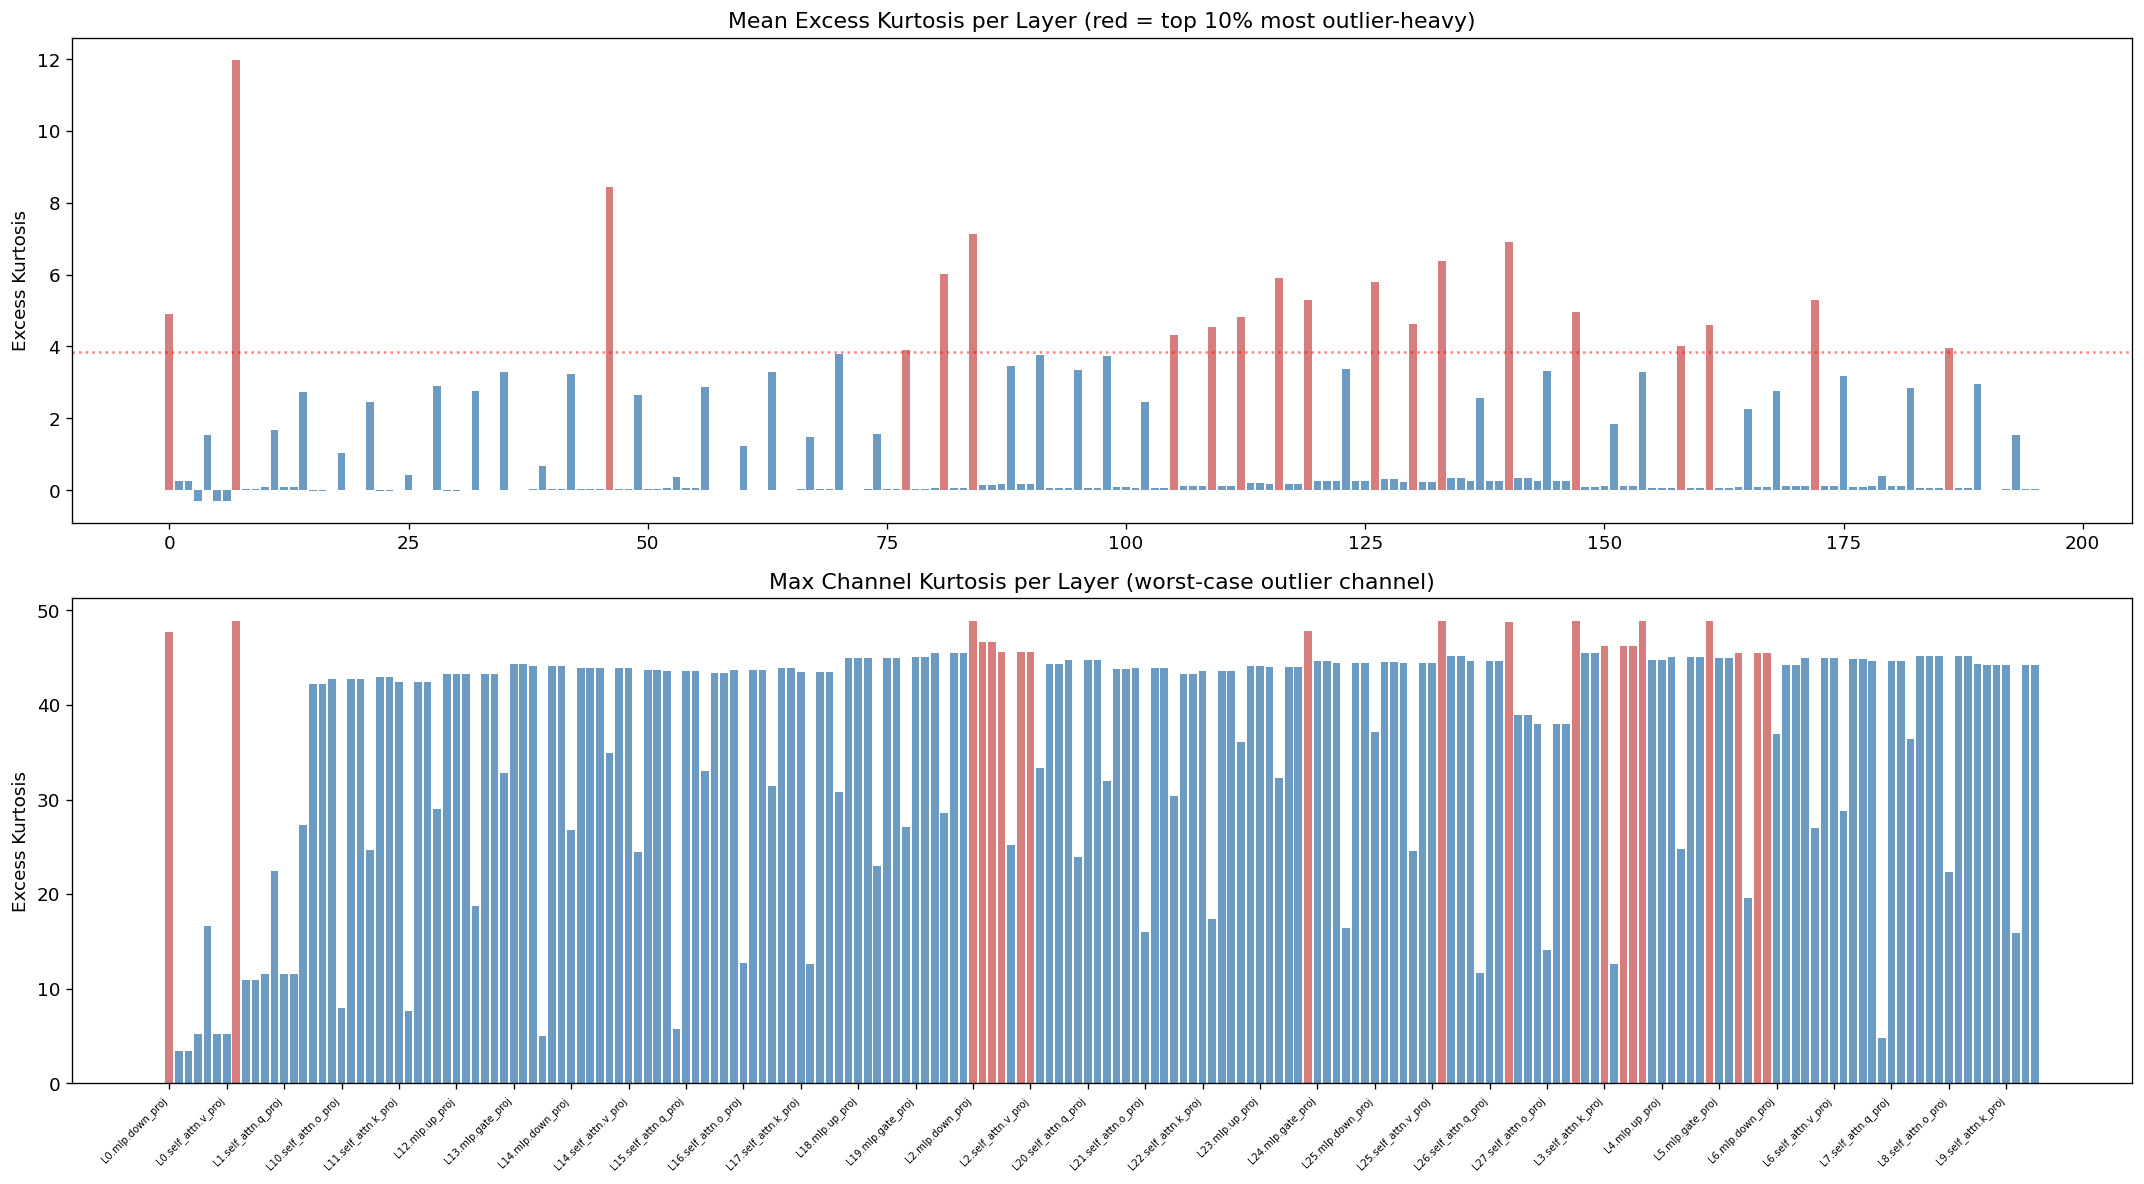


=== Top 10 Highest Mean Kurtosis Layers (最難量化) ===
  model.layers.1.mlp.down_proj                                  kurtosis=   11.99  outlier_ratio=0.003292
  model.layers.14.self_attn.o_proj                              kurtosis=    8.43  outlier_ratio=0.070174
  model.layers.2.mlp.down_proj                                  kurtosis=    7.15  outlier_ratio=0.001240
  model.layers.27.mlp.down_proj                                 kurtosis=    6.90  outlier_ratio=0.001833
  model.layers.26.mlp.down_proj                                 kurtosis=    6.38  outlier_ratio=0.001225
  model.layers.19.self_attn.o_proj                              kurtosis=    6.01  outlier_ratio=0.014172
  model.layers.23.self_attn.o_proj                              kurtosis=    5.91  outlier_ratio=0.011267
  model.layers.25.mlp.down_proj                                 kurtosis=    5.78  outlier_ratio=0.001103
  model.layers.24.mlp.down_proj                                 kurtosis=    5.30  outlier_ratio=0.0

In [13]:
# === 收集所有層的 kurtosis ===
layer_info = []  # (name, mean_kurtosis, max_kurtosis, outlier_ratio)

for name in sorted(activation_stats.keys()):
    s = activation_stats[name]
    kurt = s['kurtosis'].numpy()
    olr = s['outlier_ratio'].numpy()
    layer_info.append({
        'name': name,
        'mean_kurtosis': kurt.mean(),
        'max_kurtosis': kurt.max(),
        'mean_outlier_ratio': olr.mean(),
        'max_outlier_ratio': olr.max(),
    })

# 只看 transformer block 裡的層（過濾掉 embed/lm_head）
block_layers = [l for l in layer_info if 'layers.' in l['name']]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10))

names = [l['name'].replace('model.layers.', 'L').split('.')[-1] + '\n' + 
         l['name'].replace('model.layers.', 'L').split('.')[-2] 
         for l in block_layers]
# 簡化名稱
short_names = [l['name'].replace('model.layers.', 'L') for l in block_layers]

x = range(len(block_layers))

# Mean kurtosis
mean_k = [l['mean_kurtosis'] for l in block_layers]
colors1 = ['indianred' if k > np.percentile(mean_k, 90) else 'steelblue' for k in mean_k]
ax1.bar(x, mean_k, color=colors1, alpha=0.8)
ax1.set_title('Mean Excess Kurtosis per Layer (red = top 10% most outlier-heavy)')
ax1.set_ylabel('Excess Kurtosis')
ax1.axhline(y=np.percentile(mean_k, 90), color='red', linestyle=':', alpha=0.5)

# Max kurtosis  
max_k = [l['max_kurtosis'] for l in block_layers]
colors2 = ['indianred' if k > np.percentile(max_k, 90) else 'steelblue' for k in max_k]
ax2.bar(x, max_k, color=colors2, alpha=0.8)
ax2.set_title('Max Channel Kurtosis per Layer (worst-case outlier channel)')
ax2.set_ylabel('Excess Kurtosis')
ax2.set_xticks(x[::max(1, len(x)//30)])
ax2.set_xticklabels([short_names[i] for i in x[::max(1, len(x)//30)]], 
                     fontsize=6, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 印出 top 10 worst layers
print("\n=== Top 10 Highest Mean Kurtosis Layers (最難量化) ===")
for l in sorted(block_layers, key=lambda x: x['mean_kurtosis'], reverse=True)[:10]:
    print(f"  {l['name']:60s}  kurtosis={l['mean_kurtosis']:8.2f}  outlier_ratio={l['mean_outlier_ratio']:.6f}")

## Cell 7: ★ 核心實驗 — Bit-Width Sweep + Phase Transition 觀察

對每一層模擬 8/6/4/3/2 bit 量化，計算 weighted quantization error。

**這張圖是最重要的產出**：你會看到哪些層在 4→3 bit 時 error 突然爆炸。

In [14]:
# === Bit-width sweep: 模擬不同精度的量化 error ===

bit_widths = [8, 6, 4, 3, 2]
layer_errors = OrderedDict()  # name -> [error_at_8bit, error_at_6bit, ...]

print("Sweeping bit-widths per layer...")
for name, module in tqdm(list(model.named_modules())):
    if not isinstance(module, nn.Linear):
        continue
    if name not in activation_stats:
        continue
    if 'layers.' not in name:  # 只看 transformer blocks
        continue
    
    W = module.weight.detach().cpu().float()
    act_mag = activation_stats[name]['channel_magnitude']
    
    errors = []
    for bits in bit_widths:
        n_levels = 2 ** bits
        # Symmetric per-channel quantization
        w_max = W.abs().amax(dim=1, keepdim=True)  # per output channel
        scale = w_max / (n_levels // 2)
        scale = scale.clamp(min=1e-10)
        
        W_q = (W / scale).round().clamp(-(n_levels // 2), n_levels // 2 - 1)
        W_deq = W_q * scale
        
        # Activation-weighted error (跟 AWQ 一樣：重要 channel 的 error 權重更高)
        per_channel_mse = (W - W_deq).pow(2).mean(dim=0)  # [in_features]
        weighted_error = (per_channel_mse * act_mag).sum()
        baseline = (W.pow(2).mean(dim=0) * act_mag).sum()
        relative_error = (weighted_error / baseline.clamp(min=1e-10)).item()
        
        errors.append(relative_error)
    
    layer_errors[name] = errors

print(f"Done. Analyzed {len(layer_errors)} layers.")

Sweeping bit-widths per layer...


  0%|          | 0/371 [00:00<?, ?it/s]

Done. Analyzed 196 layers.


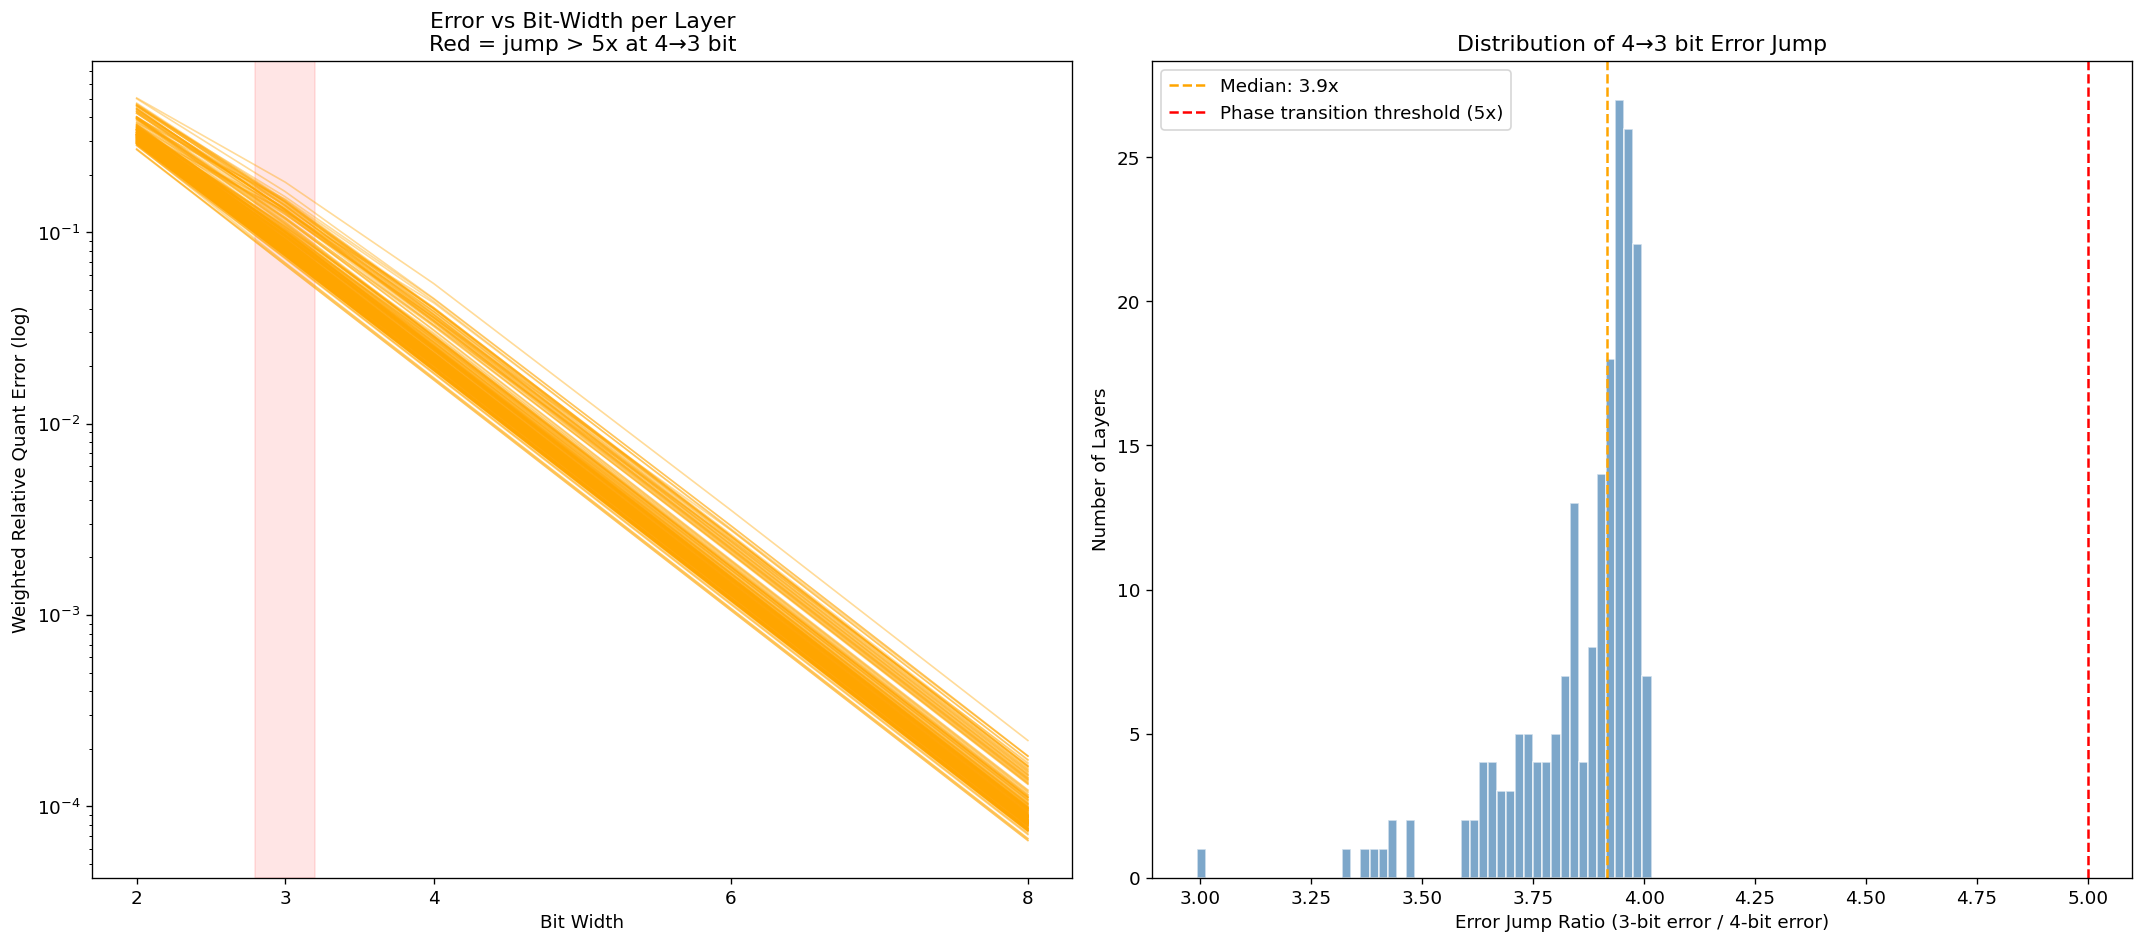


=== Top 10 Worst Phase Transition Layers (4→3 bit) ===
  model.layers.21.self_attn.k_proj                              jump=    4.02x  3bit_err=0.083787
  model.layers.10.self_attn.k_proj                              jump=    4.01x  3bit_err=0.091245
  model.layers.1.self_attn.q_proj                               jump=    4.01x  3bit_err=0.076185
  model.layers.1.self_attn.k_proj                               jump=    4.00x  3bit_err=0.073442
  model.layers.0.mlp.gate_proj                                  jump=    4.00x  3bit_err=0.077021
  model.layers.13.self_attn.k_proj                              jump=    4.00x  3bit_err=0.078339
  model.layers.3.self_attn.k_proj                               jump=    4.00x  3bit_err=0.079381
  model.layers.17.self_attn.k_proj                              jump=    4.00x  3bit_err=0.083258
  model.layers.1.mlp.gate_proj                                  jump=    3.99x  3bit_err=0.069484
  model.layers.4.self_attn.q_proj                             

In [15]:
# === 畫 Phase Transition 圖 ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# --- 左圖：所有層的 error vs bit-width ---
# 計算每層的 4→3 bit jump ratio
jump_ratios = {}
idx_4 = bit_widths.index(4)
idx_3 = bit_widths.index(3)

for name, errors in layer_errors.items():
    jump = errors[idx_3] / max(errors[idx_4], 1e-15)
    jump_ratios[name] = jump
    
    # 紅色 = 大跳躍（phase transition），灰色 = 平滑退化
    if jump > 5:
        ax1.plot(bit_widths, errors, color='red', alpha=0.7, linewidth=1.5)
    elif jump > 2:
        ax1.plot(bit_widths, errors, color='orange', alpha=0.4, linewidth=1.0)
    else:
        ax1.plot(bit_widths, errors, color='gray', alpha=0.2, linewidth=0.5)

ax1.set_xlabel('Bit Width')
ax1.set_ylabel('Weighted Relative Quant Error (log)')
ax1.set_yscale('log')
ax1.set_xticks(bit_widths)
ax1.set_title('Error vs Bit-Width per Layer\nRed = jump > 5x at 4→3 bit')
ax1.axvspan(2.8, 3.2, alpha=0.1, color='red')  # 標記 3-bit 區域

# --- 右圖：4→3 bit Jump Ratio 的分布 ---
jumps = list(jump_ratios.values())
ax2.hist(jumps, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
ax2.axvline(x=np.median(jumps), color='orange', linestyle='--', label=f'Median: {np.median(jumps):.1f}x')
ax2.axvline(x=5, color='red', linestyle='--', label='Phase transition threshold (5x)')
ax2.set_xlabel('Error Jump Ratio (3-bit error / 4-bit error)')
ax2.set_ylabel('Number of Layers')
ax2.set_title('Distribution of 4→3 bit Error Jump')
ax2.legend()

plt.tight_layout()
plt.show()

# 印出最嚴重的 phase transition layers
print("\n=== Top 10 Worst Phase Transition Layers (4→3 bit) ===")
for name, jump in sorted(jump_ratios.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {name:60s}  jump={jump:8.2f}x  3bit_err={layer_errors[name][idx_3]:.6f}")

## Cell 8: ★ Kurtosis 能否預測 Phase Transition？

**這是你論文的核心 hypothesis 驗證**

如果 kurtosis 和 jump ratio 有強相關，
你就找到了一個 lightweight phase transition predictor

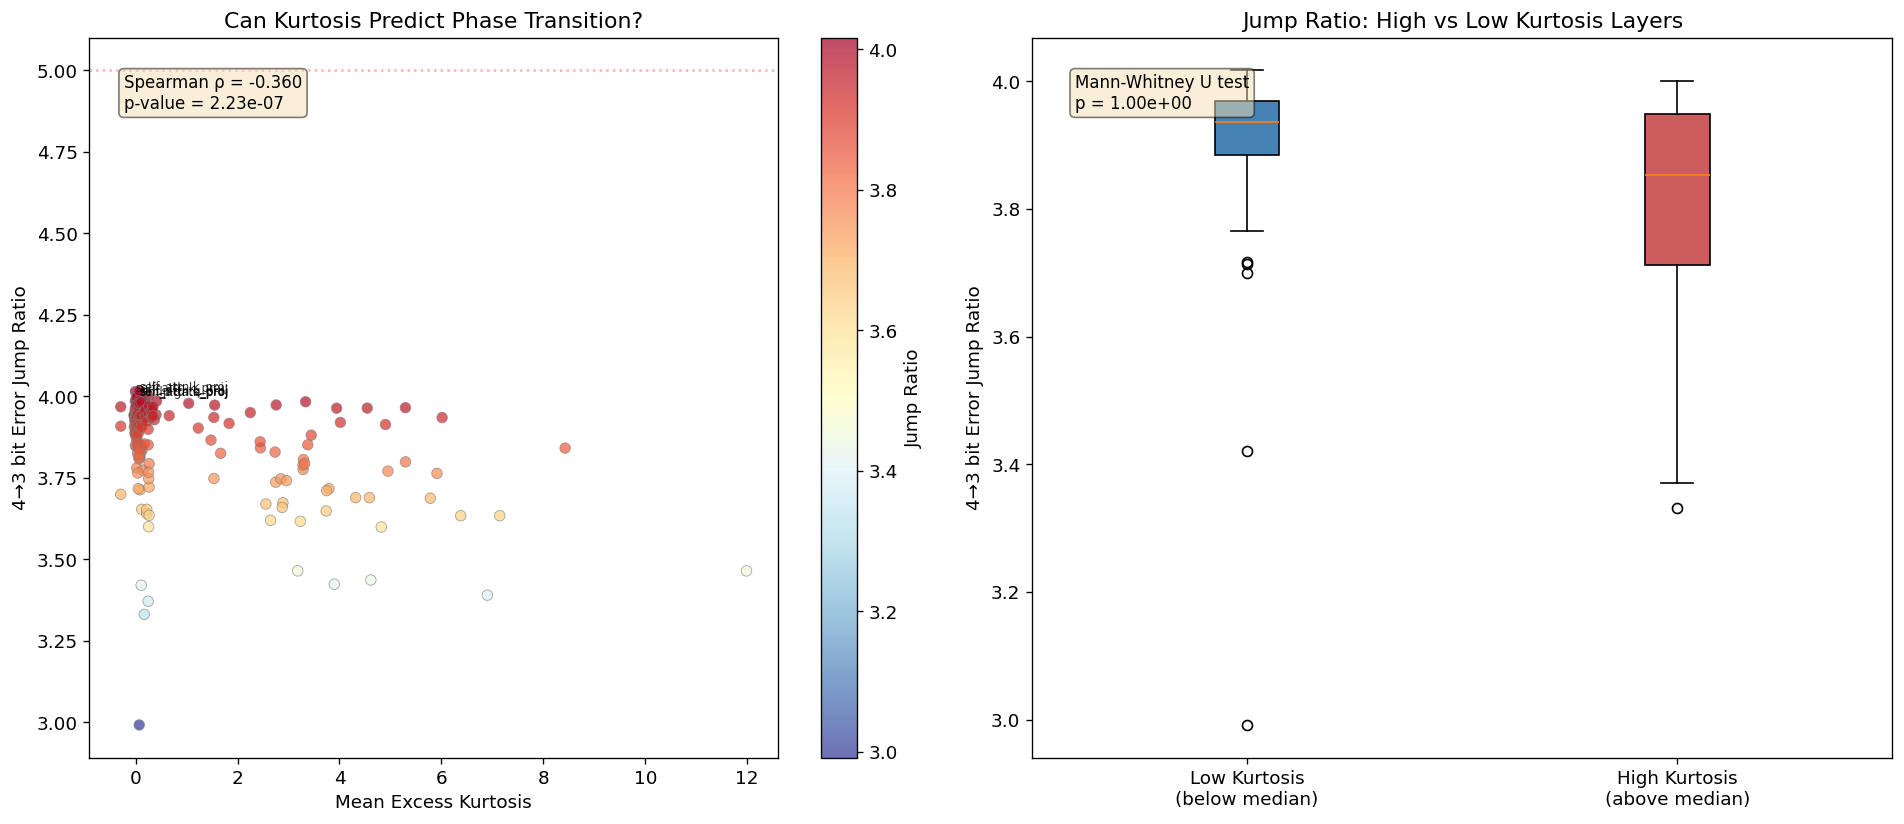


=== 結論 ===
❌ 弱相關 (ρ=-0.360)。Phase transition 的成因可能更複雜
   → 下一步：研究 inter-layer error propagation 而非 single-layer statistics


In [16]:
# === Kurtosis vs Jump Ratio 散點圖 ===

# 收集配對數據
pairs = []  # (name, kurtosis, jump_ratio)
for name in layer_errors:
    if name in activation_stats:
        kurt = activation_stats[name]['kurtosis'].mean().item()
        jump = jump_ratios[name]
        pairs.append((name, kurt, jump))

kurts = np.array([p[1] for p in pairs])
jumps_arr = np.array([p[2] for p in pairs])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- 左圖：散點圖 ---
scatter = ax1.scatter(kurts, jumps_arr, c=jumps_arr, cmap='RdYlBu_r', 
                       alpha=0.7, edgecolors='gray', linewidth=0.5, s=40)
plt.colorbar(scatter, ax=ax1, label='Jump Ratio')

# 標記最 extreme 的 layers
for name, k, j in sorted(pairs, key=lambda x: x[2], reverse=True)[:5]:
    short = name.split('.')[-2] + '.' + name.split('.')[-1]
    ax1.annotate(short, (k, j), fontsize=7, alpha=0.8)

ax1.set_xlabel('Mean Excess Kurtosis')
ax1.set_ylabel('4→3 bit Error Jump Ratio')
ax1.set_title('Can Kurtosis Predict Phase Transition?')
ax1.axhline(y=5, color='red', linestyle=':', alpha=0.3)

# Correlation
from scipy import stats as scipy_stats
corr, pval = scipy_stats.spearmanr(kurts, jumps_arr)
ax1.text(0.05, 0.95, f'Spearman ρ = {corr:.3f}\np-value = {pval:.2e}', 
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# --- 右圖：分組比較 ---
# 把 layers 分成 high-kurtosis 和 low-kurtosis 兩組
median_kurt = np.median(kurts)
high_kurt_jumps = jumps_arr[kurts > median_kurt]
low_kurt_jumps = jumps_arr[kurts <= median_kurt]

bp = ax2.boxplot([low_kurt_jumps, high_kurt_jumps],
                  tick_labels=['Low Kurtosis\n(below median)', 'High Kurtosis\n(above median)'],
                  patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('indianred')
ax2.set_ylabel('4→3 bit Error Jump Ratio')
ax2.set_title('Jump Ratio: High vs Low Kurtosis Layers')

# T-test
t_stat, t_pval = scipy_stats.mannwhitneyu(high_kurt_jumps, low_kurt_jumps, alternative='greater')
ax2.text(0.05, 0.95, f'Mann-Whitney U test\np = {t_pval:.2e}', 
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n=== 結論 ===")
if corr > 0.4 and pval < 0.01:
    print(f"✅ 強相關！Kurtosis 可以預測 phase transition (ρ={corr:.3f})")
    print("   → 這是一個有論文潛力的 finding")
    print("   → 下一步：驗證在更多模型上（3B, 7B）是否一致")
elif corr > 0.2:
    print(f"⚠️ 中等相關 (ρ={corr:.3f})。Kurtosis alone 可能不夠")
    print("   → 下一步：嘗試加入其他 predictor（spectral norm, layer depth, etc.）")
else:
    print(f"❌ 弱相關 (ρ={corr:.3f})。Phase transition 的成因可能更複雜")
    print("   → 下一步：研究 inter-layer error propagation 而非 single-layer statistics")

## Cell 9: 額外實驗 — 比較不同模型大小

如果你跑完 1B 了，換 3B 或 7B 再跑一次，
比較不同大小模型的 phase transition 嚴重程度。

**預期：小模型的 jump ratio 更大（redundancy 更少，3-bit 崩得更厲害）**

In [17]:
# === 如果你已經存了多個模型的結果 ===
# 手動把上面的 jump_ratios 存下來，然後比較

# 存當前結果
import json

save_data = {
    'model': model_name,
    'jump_ratios': {k: v for k, v in jump_ratios.items()},
    'kurtosis': {k: activation_stats[k]['kurtosis'].mean().item() 
                 for k in jump_ratios if k in activation_stats},
}

save_path = f"diagnostic_{model_name.split('/')[-1]}.json"
with open(save_path, 'w') as f:
    json.dump(save_data, f, indent=2)
print(f"Saved to {save_path}")
print("\n跑完另一個模型後，可以 load 兩個 json 來比較 jump_ratio 分布")

Saved to diagnostic_Qwen2.5-1.5B.json

跑完另一個模型後，可以 load 兩個 json 來比較 jump_ratio 分布


## 下一步方向

根據 Cell 8 的結果：

**如果 kurtosis 和 jump ratio 強相關（ρ > 0.4）：**
- 你的碩論方向：建立 phase transition predictor
- 擴展：加入更多 features（spectral norm, layer position, attention pattern entropy）
- 應用：layer-wise adaptive precision allocation（高 kurtosis 層用 4-bit，低的用 2-bit）

**如果相關性弱（ρ < 0.2）：**  
- 意味著 phase transition 不是由 single-layer 統計量決定的
- 更有可能是 **inter-layer error propagation** 造成的
- 新方向：trace quantization error through attention → FFN → residual stream
- 這反而是更 novel 的研究問題

**無論結果如何，你都拿到了 empirical evidence**，這比盲目做 W4A4 有價值得多。